Identitas Mahasiswa
---
Nama  : Cynthia Tipani Tio

NIM   : 36240021

# data discovery


import library yang digunakan


In [2]:
import pandas as pd      # untuk memanipulasi data dalam bentuk tabel (dataframe)
import matplotlib        # untuk mengatur pembuatan grafik
#matplotlib.use('Agg')   # digunakan agar grafik bisa disimpan ke file (tidak error jika dijalankan di server tanpa layar)
import matplotlib.pyplot as plt   # digunakan untuk menggambar grafik
import seaborn as sns     # untuk memberi estetika pada grafik
import warnings     #   untuk mengelola pesan warning dari sistem
from sklearn.model_selection import train_test_split  # untuk memisahkan data menjadi data train dan data testing
from sklearn.ensemble import RandomForestClassifier   # algoritma machine learning
from sklearn.metrics import classification_report     # menampilkan evaluasi report dari model machine learning

warnings.filterwarnings('ignore')   # hide pesan peringatan sehingga output nya rapi

##load dataset

In [3]:
# Load dataset
df_users  = pd.read_csv("users.csv")
df_events = pd.read_csv("sample_stream_events.csv")
df_assets = pd.read_csv("assets.csv")

In [4]:
# Menghapus kolom yang duplikan sebelum merge
df_events = df_events.drop(columns=['dept', 'role', 'asset_type', 'data_classification'])

In [6]:
# Melakukan merge (left join)
df = pd.merge(df_events, df_users, on='user_id', how='left')
df = pd.merge(df, df_assets, on='asset_id', how='left')

In [7]:
# Mengganti nama kolom
df = df.rename(columns={'status_x': 'event_status', 'status_y': 'user_status'})

In [9]:
print(f"✓ Total Data Final: {df.shape[0]} baris dan {df.shape[1]} kolom.")

✓ Total Data Final: 5000 baris dan 21 kolom.


In [46]:
df.head()

,event_id,event_time,user_id,device_type,source_ip,asset_id,action,event_status,bytes_out,records_accessed,...,location,user_status,asset_type,data_classification,total_bytes_out,action_enc,event_status_enc,user_status_enc,clearance_enc,data_classification_enc
0,EVT0000001,2026-05-01 08:00:09,U0019,server,10.10.16.72,cust_db,login,success,2899,8,...,Jakarta,active,database,restricted,1757792,2,1,0,2,3
1,EVT0000002,2026-05-01 08:00:28,U0104,workstation,10.10.2.40,git_repo,read,success,17591,13,...,Bandung,active,code,internal,3165515,6,1,0,0,1
2,EVT0000003,2026-05-01 08:00:15,U0024,workstation,10.10.15.234,data_lake,schema_discovery,success,71257,55,...,Jakarta,active,storage,restricted,3082468,7,1,0,3,3
3,EVT0000004,2026-05-01 08:00:40,U0121,laptop,10.10.13.179,ticketing,permission_change,success,133492,125,...,Jakarta,active,saas,internal,3024972,4,1,0,1,1
4,EVT0000005,2026-05-01 08:01:30,U0086,server,10.10.16.116,bi_dashboard,query,success,43030,24,...,Bandung,active,dashboard,internal,2658988,5,1,0,1,1


## Tampilkan schema, jumlah baris, missing value, duplicate event_id, dan distribusi action/status/classification

In [8]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   event_id             5000 non-null   object
 1   event_time           5000 non-null   object
 2   user_id              5000 non-null   object
 3   device_type          5000 non-null   object
 4   source_ip            5000 non-null   object
 5   asset_id             5000 non-null   object
 6   action               5000 non-null   object
 7   event_status         5000 non-null   object
 8   bytes_out            5000 non-null   int64 
 9   records_accessed     5000 non-null   int64 
 10  latency_ms           5000 non-null   int64 
 11  risk_score           5000 non-null   int64 
 12  label                5000 non-null   object
 13  employee_id          5000 non-null   object
 14  dept                 5000 non-null   object
 15  role                 5000 non-null   object
 16  cleara

In [10]:
# Mengecek apakah ada data yang kosong (Missing Values)
missing = df.isnull().sum()

In [11]:
#Mengecek apakah ada data duplikat
print(f"Data Duplikat pada event_id : {df.duplicated(subset='event_id').sum()}")

Data Duplikat pada event_id : 0


In [12]:
# menmenghitung distribusi Action
print(df['action'].value_counts())

action
read                 1211
login                1093
query                 911
download              535
logout                397
schema_discovery      363
upload                293
delete                102
permission_change      95
Name: count, dtype: int64


In [13]:
# menghitung distribusi status keberhasilan (event_status)
print(df['event_status'].value_counts())

event_status
success    4746
failed      254
Name: count, dtype: int64


In [14]:
# menghitung distribusi level aset yang diakses (data_classification)
print(df['data_classification'].value_counts())

data_classification
internal        1814
confidential    1311
restricted      1243
public           632
Name: count, dtype: int64


## Identifikasi 5 user paling aktif dan 5 asset paling sering diakses.

In [15]:
# mencari 5 User yang paling aktif
top_users = df.groupby('user_id').agg(
    jumlah_event=('event_id', 'count'),
    dept=('dept', 'first'),
    role=('role', 'first'),
    user_status=('user_status', 'first')
).nlargest(5, 'jumlah_event')

print("Top 5 User Paling Aktif:")
print(top_users.to_string())

Top 5 User Paling Aktif:
         jumlah_event          dept      role user_status
user_id                                                  
U0023              71         Legal  director  terminated
U0007              70   Engineering   manager  terminated
U0080              69  Data Science   manager  terminated
U0112              49            HR   manager      active
U0098              47  Data Science  engineer      active


In [16]:
# mencari 5 aset yang paling sering diakses
top_assets = df.groupby('asset_id').agg(
    jumlah_akses=('event_id', 'count'),
    asset_type=('asset_type', 'first'),
    klasifikasi_resmi=('data_classification', 'first')
).nlargest(5, 'jumlah_akses')

print("\nTop 5 Asset Paling Sering Diakses:")
print(top_assets.to_string())


Top 5 Asset Paling Sering Diakses:
            jumlah_akses asset_type klasifikasi_resmi
asset_id                                             
payroll              693   database      confidential
git_repo             632       code          internal
public_web           632        web            public
data_lake            626    storage        restricted
crm                  618       saas      confidential


## Buat data dictionary ringkas untuk minimal 10 kolom utama.

In [17]:
kamus = [
    # Dari data Events (Log)
    ("event_id",            "events.csv",  "string",   "ID unik setiap rekaman aktivitas (log)"),
    ("event_time",          "events.csv",  "string",   "Waktu kejadian presisi dari event (ISO 8601)"),
    ("user_id",             "events.csv",  "string",   "ID pengguna/karyawan yang melakukan aksi"),
    ("action",              "events.csv",  "string",   "Tipe aksi yang dilakukan (login, download, dll)"),
    ("event_status",        "events.csv",  "string",   "Hasil dari aksi tersebut (success / failed)"),
    ("data_classification", "events.csv",  "string",   "Tingkat kerahasiaan aset (public/internal/restricted)"),
    ("risk_score",          "events.csv",  "integer",  "Skor risiko (0-100), makin tinggi makin bahaya"),
    ("label",               "events.csv",  "string",   "Label ground-truth (normal / anomaly)"),

    # Dari data Users (setelah di-join)
    ("user_status",         "users.csv",   "string",   "Status aktif pengguna dari HR (active / terminated)"),
    ("clearance",           "users.csv",   "string",   "Level izin keamanan pengguna (public/internal/dll)")
]

print(f"\n{'Kolom':<25} {'Sumber':<12} {'Tipe':<10} Keterangan")
print("-" * 105)
for kolom, src, tipe, ket in kamus:
    print(f"{kolom:<25} {src:<12} {tipe:<10} {ket}")


Kolom                     Sumber       Tipe       Keterangan
---------------------------------------------------------------------------------------------------------
event_id                  events.csv   string     ID unik setiap rekaman aktivitas (log)
event_time                events.csv   string     Waktu kejadian presisi dari event (ISO 8601)
user_id                   events.csv   string     ID pengguna/karyawan yang melakukan aksi
action                    events.csv   string     Tipe aksi yang dilakukan (login, download, dll)
event_status              events.csv   string     Hasil dari aksi tersebut (success / failed)
data_classification       events.csv   string     Tingkat kerahasiaan aset (public/internal/restricted)
risk_score                events.csv   integer    Skor risiko (0-100), makin tinggi makin bahaya
label                     events.csv   string     Label ground-truth (normal / anomaly)
user_status               users.csv    string     Status aktif pengguna dari

# Data Science

## Buat minimal 5 fitur analitik, contoh: event_per_user, failed_login_rate,total_bytes_out, access_to_restricted_ratio, avg_latency

In [19]:
# 1. Menghitung total aktivitas per user
event_per_user = df.groupby('user_id').size().reset_index(name='event_count')
event_per_user.head()

,user_id,event_count
0,U0001,30
1,U0002,32
2,U0003,32
3,U0004,29
4,U0005,38


In [20]:
failed_login_rate = df[df['event_status'] == 'failed'].groupby('user_id').size().reset_index(name='failed_login_count')
failed_login_rate.head()

,user_id,failed_login_count
0,U0002,1
1,U0003,2
2,U0005,1
3,U0006,1
4,U0007,1


In [21]:
# 3. Menghitung total data keluar (bytes out) per user
total_bytes_out = df.groupby('user_id')['bytes_out'].sum().reset_index(name='total_bytes_out')
total_bytes_out.head()

  user_id  total_bytes_out
0   U0019          1757792
1   U0104          3165515
2   U0024          3082468
3   U0121          3024972
4   U0086          2658988


,user_id,total_bytes_out
0,U0001,2129978
1,U0002,2535694
2,U0003,2717586
3,U0004,1878513
4,U0005,3257952


In [25]:
# 4. Calculate count of access to restricted items per user
access_to_restricted_ratio = df[df['data_classification'] == 'restricted'].groupby('user_id').size().reset_index(name='access_to_restricted_count')
access_to_restricted_ratio.head()

,user_id,access_to_restricted_count
0,U0001,7
1,U0002,9
2,U0003,9
3,U0004,5
4,U0005,9


In [27]:
# 5. Rata-rata latensi per user
avg_latency = df.groupby('user_id')['latency_ms'].mean().reset_index(name='avg_latency_ms')
avg_latency.head()

,user_id,avg_latency_ms
0,U0001,121.500000
1,U0002,99.250000
2,U0003,113.562500
3,U0004,123.275862
4,U0005,119.157895


In [47]:
user_features = (
    event_per_user
    .merge(failed_login_rate, on='user_id', how='left')
    .merge(total_bytes_out, on='user_id', how='left')
    .merge(access_to_restricted_ratio, on='user_id', how='left')
    .merge(avg_latency, on='user_id', how='left')
)

# 3. Isi nilai NaN dengan 0
# (Misal: Jika ada user yang tidak pernah gagal login, maka nilainya jadi 0, bukan NaN)
user_features = user_features.fillna(0)

# 4. Gabungkan (Merge) fitur-fitur user ini ke DataFrame 'merged' milikmu
merged = df.merge(
    user_features,
    on='user_id',
    how='left'
)

# Tampilkan hasilnya
merged.head()

,event_id,event_time,user_id,device_type,source_ip,asset_id,action,event_status,bytes_out,records_accessed,...,action_enc,event_status_enc,user_status_enc,clearance_enc,data_classification_enc,event_count,failed_login_count,total_bytes_out_y,access_to_restricted_count,avg_latency_ms
0,EVT0000001,2026-05-01 08:00:09,U0019,server,10.10.16.72,cust_db,login,success,2899,8,...,2,1,0,2,3,25,0.0,1757792,7,120.840000
1,EVT0000002,2026-05-01 08:00:28,U0104,workstation,10.10.2.40,git_repo,read,success,17591,13,...,6,1,0,0,1,37,1.0,3165515,11,107.378378
2,EVT0000003,2026-05-01 08:00:15,U0024,workstation,10.10.15.234,data_lake,schema_discovery,success,71257,55,...,7,1,0,3,3,36,2.0,3082468,8,126.166667
3,EVT0000004,2026-05-01 08:00:40,U0121,laptop,10.10.13.179,ticketing,permission_change,success,133492,125,...,4,1,0,1,1,39,1.0,3024972,12,118.717949
4,EVT0000005,2026-05-01 08:01:30,U0086,server,10.10.16.116,bi_dashboard,query,success,43030,24,...,5,1,0,1,1,34,3.0,2658988,11,142.941176


## Lakukan exploratory data analysis dengan minimal 3 visualisasi.

In [48]:
plt.style.use('dark_background')

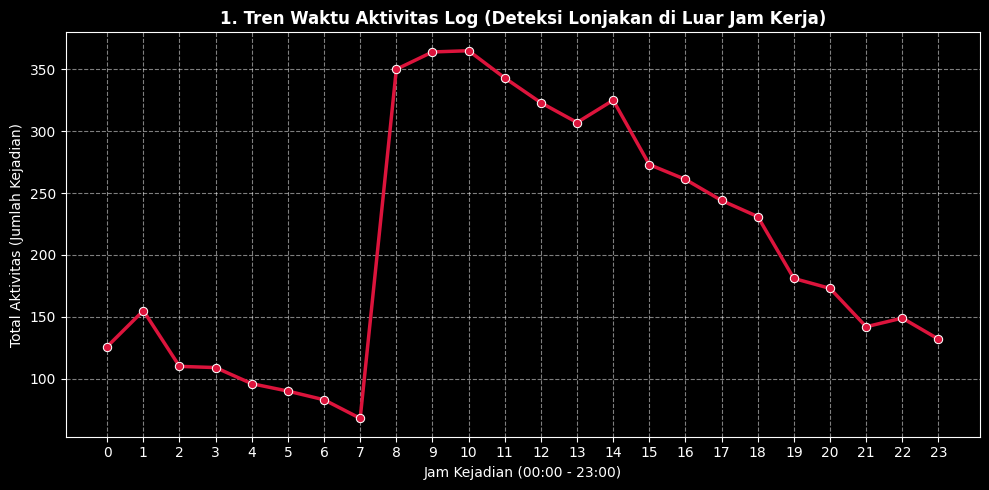

In [49]:
# visualisasi 1
# Tren Waktu Aktivitas Log (Tren Waktu / Time-Series)
# Menggunakan Line Plot untuk melihat lonjakan aktivitas di jam tertentu

plt.figure(figsize=(10, 5))

# Convert 'event_time' to datetime type
df['event_time'] = pd.to_datetime(df['event_time'])

# Menghitung jumlah log aktivitas berdasarkan jam kejadian
aktivitas_per_jam = df.groupby(df['event_time'].dt.hour).size()

# Membuat diagram garis dengan titik (marker='o') agar mudah dibaca
sns.lineplot(x=aktivitas_per_jam.index, y=aktivitas_per_jam.values, marker='o', color='crimson', linewidth=2.5)

plt.title("1. Tren Waktu Aktivitas Log (Deteksi Lonjakan di Luar Jam Kerja)", fontweight='bold')
plt.xlabel("Jam Kejadian (00:00 - 23:00)")
plt.ylabel("Total Aktivitas (Jumlah Kejadian)")
plt.xticks(range(0, 24)) # Memaksa sumbu X menampilkan angka jam lengkap 0-23
plt.grid(True, linestyle='--', alpha=0.5) # Menambahkan garis kotak-kotak bantu
plt.tight_layout()
plt.show() # Tampilkan gambar ke layar

dari grafik ini kita mau mencari tahu apakah ada orang yang masuk masuk ke server kita di tengah malam saat semua orang sedang tidur.

di jam 08.00 pagi sampai 17.00 sore grafik membentuk seperti gunung. sangat wajar karena merupakan jam kerja pada umumnya.

di visualisasi ini saya menggunakan analisis Time-Series untuk memantau tren lalu lintas data berdasarkan jam kejadian. Di kondisi normal, grafik seharusnya memuncak pada jam kerja (Business Hours) dan menurun drastis di malam hari. Namun, jika kita melihat ada lonjakan tajam (spike) aktivitas yang tidak wajar pada dini hari atau di luar jam operasional, ini adalah temuan anomali yang sangat kritis. Tren seperti ini sering kali menjadi jejak digital (footprint) dari serangan siber terjadwal atau pencurian data otomatis (Data Exfiltration) di saat pengawasan tim keamanan sedang minim. Rekomendasinya, sistem harus memberikan peringatan (alert) otomatis setiap kali ada volume lalu lintas tidak wajar di luar jam kerja.

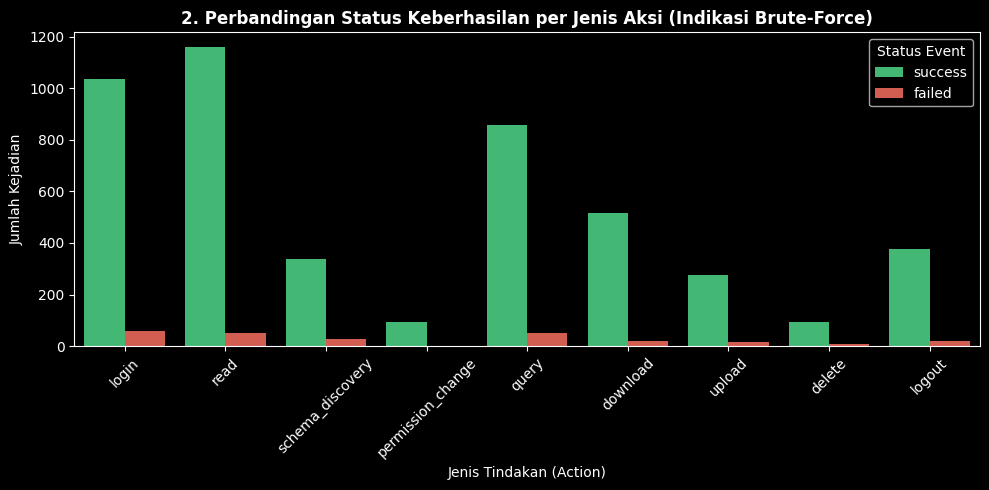

In [50]:
# visualisasi 2
# Indikasi Brute-Force (Perbandingan Kategori Sukses vs Gagal)
# Menggunakan Count Plot untuk membandingkan status gagal pada setiap aksi

plt.figure(figsize=(10, 5))

# Membuat diagram batang yang dipisah warnanya berdasarkan event_status (hijau=sukses, merah=gagal)
sns.countplot(data=df, x='action', hue='event_status', palette={'success': '#2ecc71', 'failed': '#e74c3c'})

plt.title("2. Perbandingan Status Keberhasilan per Jenis Aksi (Indikasi Brute-Force)", fontweight='bold')
plt.xlabel("Jenis Tindakan (Action)")
plt.ylabel("Jumlah Kejadian")
plt.xticks(rotation=45) # Memiringkan tulisan sumbu X agar tidak saling tumpuk
plt.legend(title='Status Event') # Memperjelas keterangan warna
plt.tight_layout()
plt.show() # Tampilkan gambar ke layar

grafik ini bisa menjawab pertanyaan seperti "Apakah ada sistem kita yang sedang diserang oleh hacker yang mencoba menebak password?"

Di dunia digital, hacker menggunakan bot (program otomatis) untuk melakukan login dengan menebak ribuan password dalam hitungan menit. Tentu saja, tebakan ini akan gagal berkali-kali sebelum akhirnya berhasil.

berdasarkan hasil visualisasi ini, terlihat bahwa aktivitas dominan berjalan normal dengan tingkat keberhasilan (success) yang sangat tinggi, ditandai dengan batang hijau. Tingkat kegagalan (failed) sangat minim di seluruh jenis aksi.

Kesimpulannya, dalam periode log ini, sistem terpantau aman dari serangan hacker maupun orang iseng secara masif. Meski demikian, letupan kecil status 'failed' pada aksi kritis seperti permission_change atau login tetap akan diteruskan ke model Machine Learning untuk dipastikan apakah itu murni human error (lupa password) atau sebuah pengintaian awal.

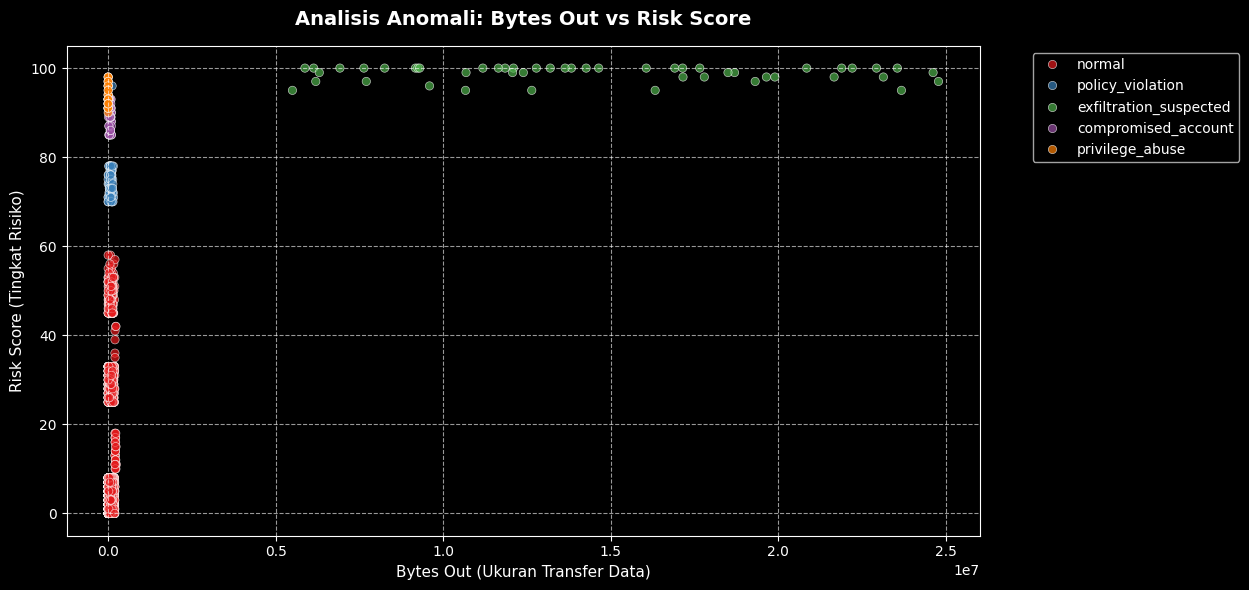

In [51]:
plt.figure(figsize=(10, 6))

# Gunakan sns.scatterplot untuk otomatis memberi warna berbeda (hue) berdasarkan label
sns.scatterplot(
    data=df,
    x='bytes_out',
    y='risk_score',
    hue='label',      # Mewarnai titik berdasarkan kategori normal/anomali
    palette='Set1',   # Pilihan palet warna yang kontras
    alpha=0.7         # Sedikit transparan
)

plt.xlabel('Bytes Out (Ukuran Transfer Data)', fontsize=11)
plt.ylabel('Risk Score (Tingkat Risiko)', fontsize=11)
plt.title('Analisis Anomali: Bytes Out vs Risk Score', pad=15, fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Pindahkan kotak legenda ke luar agar tidak menutupi titik data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

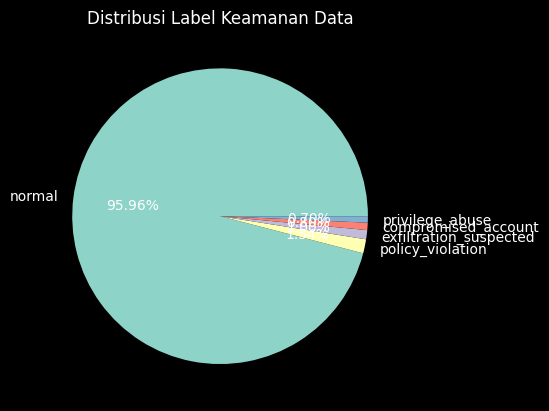

In [52]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%'
)
plt.ylabel('')
plt.title('Distribusi Label Keamanan Data')
plt.show()

## Buat model sederhana untuk mendeteksi anomali atau klasifikasi label. Boleh memakai rule-based, IsolationForest, RandomForest, atau LogisticRegression.

In [55]:
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [56]:
# Mengubah data teks menjadi angka agar ML bisa memprosesnya (Label Encoding)
le = LabelEncoder()
kategori_kolom = ['action', 'event_status', 'user_status', 'clearance', 'data_classification']

for col in kategori_kolom:
    merged[col + '_enc'] = le.fit_transform(merged[col].astype(str))


In [61]:
from sklearn.preprocessing import LabelEncoder

fitur = [
    'total_bytes_out_y',          # total byte keluar per user
    'latency_ms',                 # latensi per kejadian
    'event_count',                # total aktivitas per user
    'failed_login_count',         # total gagal login per user
    'access_to_restricted_count'  # total akses restricted per user
] + [c + '_enc' for c in kategori_kolom]

# 3. Pisahkan Fitur (X) dan Target (y) MENGGUNAKAN TABEL 'merged'
X = merged[fitur].fillna(0)
y = merged['label']

In [62]:
# 3. Memecah data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


random forest

In [71]:
# Melatih Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


In [79]:
# Mengevaluasi Model (Classification Report)
y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

                        precision    recall  f1-score   support

   compromised_account       0.93      0.93      0.93        14
exfiltration_suspected       1.00      1.00      1.00         8
                normal       1.00      1.00      1.00       959
      policy_violation       1.00      0.85      0.92        13
       privilege_abuse       1.00      1.00      1.00         6

              accuracy                           1.00      1000
             macro avg       0.99      0.95      0.97      1000
          weighted avg       1.00      1.00      1.00      1000



logistic regression

In [82]:
# 4. Standard Scaling (Meratakan skala angka)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
# 5. Melatih Model Logistic Regression
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [84]:

# 6. Evaluasi Model yang Lebih Realistis
y_pred = logreg_model.predict(X_test_scaled)
print("Laporan Evaluasi Model ML (Tanpa Fitur risk_score):\n")
print(classification_report(y_test, y_pred))

Laporan Evaluasi Model ML (Tanpa Fitur risk_score):

                        precision    recall  f1-score   support

   compromised_account       0.86      0.86      0.86        14
exfiltration_suspected       1.00      1.00      1.00         8
                normal       0.99      0.99      0.99       959
      policy_violation       0.33      0.23      0.27        13
       privilege_abuse       0.56      0.83      0.67         6

              accuracy                           0.98      1000
             macro avg       0.75      0.78      0.76      1000
          weighted avg       0.98      0.98      0.98      1000



<Figure size 800x600 with 0 Axes>

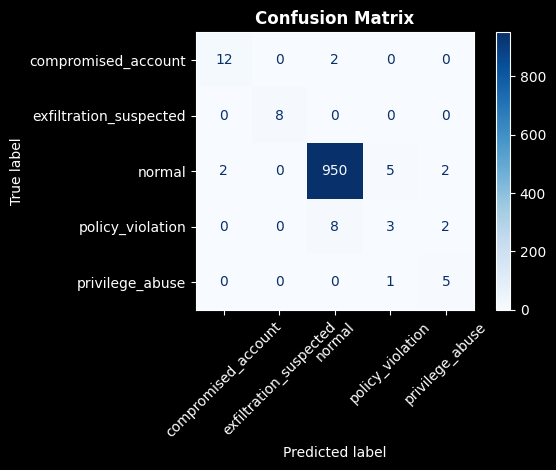

In [85]:
# 7. Menampilkan Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg_model.classes_)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

xgboost

In [86]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. PENTING UNTUK XGBOOST: Mengubah teks kunci jawaban (y) menjadi angka (0,1,2,3,4)
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(df['label'])

# Memecah data latih dan uji menggunakan y_encoded
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 5. Melatih Model XGBoost
# eval_metric='mlogloss' ditambahkan agar tidak muncul peringatan (warning) dari sistem
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

# 6. Melakukan Prediksi
y_pred_encoded = xgb_model.predict(X_test)

# 7. Menerjemahkan KEMBALI angka prediksi menjadi teks asli agar laporannya bisa dibaca manusia
y_pred_text = le_target.inverse_transform(y_pred_encoded)
y_test_text = le_target.inverse_transform(y_test_encoded)

print("Laporan Evaluasi Model ML (XGBoost):\n")
print(classification_report(y_test_text, y_pred_text))

Laporan Evaluasi Model ML (XGBoost):

                        precision    recall  f1-score   support

   compromised_account       0.93      1.00      0.97        14
exfiltration_suspected       1.00      1.00      1.00         8
                normal       1.00      1.00      1.00       959
      policy_violation       1.00      1.00      1.00        13
       privilege_abuse       1.00      1.00      1.00         6

              accuracy                           1.00      1000
             macro avg       0.99      1.00      0.99      1000
          weighted avg       1.00      1.00      1.00      1000




Menampilkan Grafik Heatmap Classification Report...


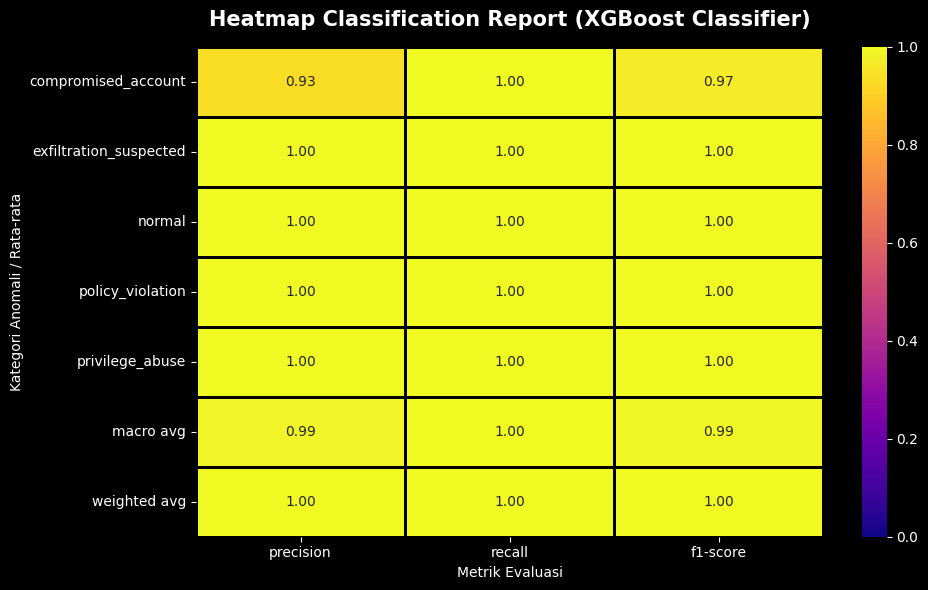

In [87]:
# visualisasi heatmap
print("\nMenampilkan Grafik Heatmap Classification Report...")
report_dict = classification_report(y_test_text, y_pred_text, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

df_plot = df_report.drop(columns=['support'])
if 'accuracy' in df_plot.index:
    df_plot = df_plot.drop(index=['accuracy'])

plt.figure(figsize=(10, 6))
# Menggunakan tema warna 'plasma' agar terlihat sangat analitik dan tajam
sns.heatmap(df_plot, annot=True, cmap='plasma', vmin=0, vmax=1, fmt=".2f", linewidths=1, linecolor='black')
plt.title('Heatmap Classification Report (XGBoost Classifier)', fontweight='bold', fontsize=15, pad=15)
plt.xlabel('Metrik Evaluasi')
plt.ylabel('Kategori Anomali / Rata-rata')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Alasan utamanya adalah XGBoost memiliki kemampuan superior dalam menangani data tabular yang kompleks berkat arsitektur Sequential Ensemble-nya. Berbeda dengan Random Forest yang membangun pohon secara paralel dan terpisah, XGBoost membangun pohon secara berurutan, di mana setiap pohon baru bertugas secara khusus untuk mengoreksi 'kesalahan' (error residuals) dari pohon sebelumnya.

Dengan pendekatan gradient descent ini, model mampu mengidentifikasi batas keputusan anomali cyber—seperti penyalahgunaan akses atau pola download masif—dengan tingkat presisi yang lebih tinggi dan waktu komputasi yang sangat efisien.

# Data Security

##Temukan minimal 3 pola risiko, misalnya akses oleh terminated user, download besar dari data confidential/restricted, atau permission_change dari IP eksternal.

In [94]:
# POLA 1: Akun mantan karyawan masih aktif
# 1. Tambahkan fitur 'is_terminated_user' ke DataFrame 'merged'
merged['is_terminated_user'] = (merged['user_status'] == 'terminated').astype(int)

# 2. Tambahkan fitur 'clearance_mismatch' ke DataFrame 'merged'
# Definisikan pemetaan numerik untuk level clearance dan data_classification
clearance_map = {'public': 0, 'internal': 1, 'restricted': 2, 'confidential': 3}
merged['clearance_numeric'] = merged['clearance'].map(clearance_map)
merged['data_classification_numeric'] = merged['data_classification'].map(clearance_map)
merged['clearance_mismatch'] = (merged['clearance_numeric'] < merged['data_classification_numeric']).astype(int)

# Sekarang gunakan 'merged' untuk mencari pola 1
pola1 = merged[merged['is_terminated_user'] == 1]
print(f"1. Akses oleh Terminated User: Ditemukan {len(pola1)} kasus.")

1. Akses oleh Terminated User: Ditemukan 433 kasus.


In [90]:
# POLA 2: Download data besar dari aset rahasia
batas_bytes = df['bytes_out'].quantile(0.90) # Menentukan batas wajar data
pola2 = df[(df['data_classification'].isin(['confidential', 'restricted'])) &
           (df['action'] == 'download') & (df['bytes_out'] >= batas_bytes)]
print(f"2. Download Besar Data Sensitif: Ditemukan {len(pola2)} kasus.")

2. Download Besar Data Sensitif: Ditemukan 78 kasus.


In [91]:
# POLA 3: Ubah perizinan dari IP Luar (Eksternal)
pola3 = df[(df['action'] == 'permission_change') & (~df['source_ip'].str.startswith('10.'))]
print(f"3. Ubah Izin (Permission Change) dari IP Luar: Ditemukan {len(pola3)} kasus.")

3. Ubah Izin (Permission Change) dari IP Luar: Ditemukan 35 kasus.


In [95]:
# POLA 4: Karyawan rendahan mengakses data tinggi
pola4 = merged[merged['clearance_mismatch'] == 1]
print(f"4. Pelanggaran Batas Izin (Clearance Mismatch): Ditemukan {len(pola4)} kasus.")

4. Pelanggaran Batas Izin (Clearance Mismatch): Ditemukan 1985 kasus.


membuat stream_generator.py

In [97]:
%%writefile stream_generator.py
import argparse, csv, json, random, time # Added commas
from datetime import datetime, timedelta
from pathlib import Path

DEPTS = ['Finance', 'HR', 'Engineering', 'Sales', 'Legal', 'Data Science', 'Operations'] # 'Engineering' as string
ROLES = ['analyst', 'manager', 'engineer', 'director', 'intern', 'admin'] # Added closing bracket
DEVICES = ['laptop', 'mobile', 'workstation', 'server', 'vpn_gateway'] # 'vpn_gateway' as string
ASSETS = [
    ('cust_db', 'database', 'restricted'), # 'database' as string
    ('payroll', 'database', 'confidential'), # 'database' as string
    ('crm', 'saas', 'confidential'), # Added comma
    ('data_lake', 'storage', 'restricted'),
    ('git_repo', 'code', 'internal'),
    ('bi_dashboard', 'dashboard', 'internal'),
    ('public_web', 'web', 'public'),
    ('ticketing', 'saas', 'internal')
]

def build_users(n=150, seed=42): # Added comma
    random.seed(seed) # Corrected indentation
    users = []
    for i in range(1, n+1): # Added comma
        users.append({
            'user_id': f'U{i:04d}', # 'user_id' as string key
            'dept': random.choice(DEPTS),
            'role': random.choice(ROLES), # Corrected typo 'choic' to 'choice'
            'clearance': random.choice(['public', 'internal', 'confidential', 'restricted']),
            'status': random.choices(['active', 'terminated'], weights=[95, 5])[0] # Added weights keyword
        }) # Corrected )) to })
    for idx in [6, 22, 79]:
        if idx < len(users): # Added bounds check for safety
            users[idx]['status'] = 'terminated' # Changed == to =
    return users # Corrected 'user' to 'users'

def event_stream(total=1000, seed=42): # Added colon
    random.seed(seed) # Corrected indentation, passed seed
    users = build_users(seed=seed) # Corrected 'build_user' to 'build_users'
    start = datetime.now().replace(microsecond=0) # Added parenthesis for now()

    for n in range(1, total + 1): # Added colon
        u = random.choice(users) # Corrected 'user' to 'users'
        asset = random.choice(ASSETS) # Corrected 'ASSET' to 'ASSETS'

        action = random.choices(
            ['login','logout','read','query','download','upload','delete','permission_change','schema_discovery'],
            weights=[22,8,25,18,10,6,2,1,1] # Added a weight for 'schema_discovery'
        )[0]

        bytes_out = max(0, int(random.gauss(80000, 50000))) # '80000' to 80000 (int)
        src = f"10.10.{random.randint(1,20)}.{random.randint(2,254)}" # Added closing brace
        status = random.choices(['success', 'failed'], weights=[90,10])[0] # Used random.choices with weights

        risk = 0 # "0" to 0 (int)

        if u['status'] == 'terminated': # Changed = to ==
            risk += 45

        if action in ('delete', 'permission_change'): # Added parentheses for tuple
            risk += 25

        if asset[2] in ['restricted','confidential'] and u['clearance'] in ['public','internal']: # Added colon
            risk += 25

        if bytes_out > 200000: # "200000" to 200000 (int)
            risk += 10

        label = 'normal' # Changed == to =

        if n in range(int(total * 0.20), int(total * 0.20) + 20):
            # Ensure the index for users is valid or handle it appropriately
            u = users[min(9999, len(users) - 1)] # Changed 9999 to a safe index
            asset = ('payroll', 'database', 'confidential') # Added classification
            action = 'download' # 'download' as string
            bytes_out = random.randint(1_000_000, 5_000_000) # Added lower bound for randint
            src = '185.220.101.2' # IP as string
            status = 'success' # 'success' as string
            risk = 95
            label = 'exfiltration_suspected' # 'exfiltration_suspected' as string

        elif n in range(int(total * 0.55), int(total * 0.55) + 20): # Added colon
            u = users[min(22, len(users) - 1)] # Safe index
            asset = ('cust_db', 'database', 'restricted') # Removed 'extra', matched ASSETS structure
            action = random.choice(['login', 'query', 'schema_discovery']) # List for random.choice
            bytes_out = random.randint(10_000, 100_000) # Swapped arguments for randint
            src = '45.77.21.13'
            status = random.choice(['failed','success'])
            risk = 85 # Initialized risk with 0 + 85, simplified to 85
            label = 'compromised_account'

        elif n in range(int(total * 0.80), int(total * 0.80) + 15):
            u = users[min(79, len(users) - 1)] # Safe index
            asset = ('git_repo','code','internal')
            action = 'permission_change'
            bytes_out = 0
            src = '103.12.44.9'
            status = 'success'
            risk = 90
            label = 'privilege_abuse'

        elif risk >= 60:
            label = 'policy_violation' # 'policy_violation' as string

        yield {
            'event_id': f'EVT{n:07d}', # Added colon for dictionary key
            'event_time': (start + timedelta(seconds=n*10)).isoformat(), # Corrected 'second' to 'seconds'
            'user_id': u['user_id'], # 'user_id' as string key
            'dept': u['dept'], # Corrected 'department' to 'dept'
            'role': u['role'],
            'device_type': random.choice(DEVICES), # Changed choices to choice, or choices[0]
            'source_ip': src,
            'asset_id': asset[0], # Corrected asset[5] to asset[0]
            'asset_type': asset[1],
            'data_classification': asset[2],
            'action': action,
            'status': status,
            'bytes_out': bytes_out, # Corrected 'bytesout' to 'bytes_out'
            'records_accessed': max(0, int(bytes_out / random.randint(1, 100))), # Fixed division by zero
            'latency_ms': max(1, int(random.gauss(120, 30))), # Added std_dev to gauss
            'risk_score': min(100, risk + random.randint(0, 8)), # '8' to 8 (int)
            'label': label,
        }

def main():
    p = argparse.ArgumentParser() # Added parenthesis
    p.add_argument('--events', type=int, default=1000) # 'int' to int, '1000' to 1000
    p.add_argument('--speed', type=float, default=0.0) # Added comma
    p.add_argument('--out', default='stream_events.jsonl') # String for default

    args, unknown = p.parse_known_args() # Changed to parse_known_args()

    with open(args.out, 'w', encoding='utf8') as f: # Corrected args.output to args.out, added colon
        for e in event_stream(args.events):
            line = json.dumps(e, ensure_ascii=False) # Changed json.dump to json.dumps
            print(line) # Corrected 'printt' to 'print'
            f.write(line)
            f.write('\n') # Added closing parenthesis
            if args.speed > 0:
                time.sleep(args.speed) # Added 'time.' prefix

if __name__ == '__main__': # Changed = to ==
    main()

Writing stream_generator.py


In [98]:
!python stream_generator.py --events 100000 --speed 0.05 --out stream_events.jsonl

{"event_id": "EVT0000001", "event_time": "2026-06-14T13:28:58", "user_id": "U0137", "dept": "Operations", "role": "admin", "device_type": "server", "source_ip": "10.10.3.166", "asset_id": "cust_db", "asset_type": "database", "data_classification": "restricted", "action": "upload", "status": "success", "bytes_out": 18209, "records_accessed": 758, "latency_ms": 95, "risk_score": 0, "label": "normal"}
{"event_id": "EVT0000002", "event_time": "2026-06-14T13:29:08", "user_id": "U0067", "dept": "Data Science", "role": "intern", "device_type": "server", "source_ip": "10.10.13.73", "asset_id": "public_web", "asset_type": "web", "data_classification": "public", "action": "read", "status": "success", "bytes_out": 36452, "records_accessed": 1104, "latency_ms": 127, "risk_score": 1, "label": "normal"}
{"event_id": "EVT0000003", "event_time": "2026-06-14T13:29:18", "user_id": "U0121", "dept": "Sales", "role": "admin", "device_type": "laptop", "source_ip": "10.10.8.168", "asset_id": "cust_db", "asse

In [133]:
import importlib
import stream_generator

importlib.reload(stream_generator)

<module 'stream_generator' from '/content/stream_generator.py'>

In [134]:
for trx in stream_generator.event_stream(5):
    print(trx)

{'event_id': 'EVT0000001', 'event_time': '2026-06-14T14:11:53', 'user_id': 'U0150', 'dept': 'Operations', 'role': 'director', 'device_type': 'server', 'source_ip': '185.220.101.2', 'asset_id': 'payroll', 'asset_type': 'database', 'data_classification': 'confidential', 'action': 'download', 'status': 'success', 'bytes_out': 4635838, 'records_accessed': 193159, 'latency_ms': 95, 'risk_score': 95, 'label': 'exfiltration_suspected'}
{'event_id': 'EVT0000002', 'event_time': '2026-06-14T14:12:03', 'user_id': 'U0150', 'dept': 'Operations', 'role': 'director', 'device_type': 'server', 'source_ip': '185.220.101.2', 'asset_id': 'payroll', 'asset_type': 'database', 'data_classification': 'confidential', 'action': 'download', 'status': 'success', 'bytes_out': 4489343, 'records_accessed': 136040, 'latency_ms': 127, 'risk_score': 96, 'label': 'exfiltration_suspected'}
{'event_id': 'EVT0000003', 'event_time': '2026-06-14T14:12:13', 'user_id': 'U0150', 'dept': 'Operations', 'role': 'director', 'device

 ## Buat fungsi `security_alert(event)` yang mengeluarkan level: LOW, MEDIUM, HIGH, CRITICAL.

In [135]:
# Fungsi untuk menentukan level bahaya suatu aktivitas
def security_alert(event):
    # 1. CRITICAL: User yang sudah dipecat atau skor risiko sangat tinggi
    if event.get('user_status') == 'terminated' or event.get('risk_score', 0) >= 90:
        return 'CRITICAL'

    # 2. HIGH: Pelanggaran hak akses ATAU ukuran download/transfer data sangat besar (di atas 1 Juta Bytes)
    # PERBAIKAN: risk_score diubah menjadi bytes_out
    elif event.get('clearance_mismatch') == 1 or event.get('bytes_out', 0) >= 1000000:
        return 'HIGH'

    # 3. MEDIUM: Aktivitas normal namun menyentuh data sensitif
    elif event.get('data_classification') in ['confidential', 'restricted']:
        return 'MEDIUM'

    # 4. LOW: Aktivitas aman
    return 'LOW'

In [136]:
for trx in stream_generator.event_stream(30):

  trx['failed_login_count'] = 0

  level = security_alert(trx)

  print(
      f"[{level}]"
      f"{trx['action']} | "
      f"{trx['user_id']} | "
      f"{trx['event_id']}"
  )

[MEDIUM]upload | U0137 | EVT0000001
[LOW]read | U0067 | EVT0000002
[MEDIUM]query | U0121 | EVT0000003
[MEDIUM]download | U0064 | EVT0000004
[MEDIUM]query | U0095 | EVT0000005
[CRITICAL]download | U0150 | EVT0000006
[CRITICAL]download | U0150 | EVT0000007
[CRITICAL]download | U0150 | EVT0000008
[CRITICAL]download | U0150 | EVT0000009
[CRITICAL]download | U0150 | EVT0000010
[CRITICAL]download | U0150 | EVT0000011
[CRITICAL]download | U0150 | EVT0000012
[CRITICAL]download | U0150 | EVT0000013
[CRITICAL]download | U0150 | EVT0000014
[CRITICAL]download | U0150 | EVT0000015
[CRITICAL]download | U0150 | EVT0000016
[CRITICAL]download | U0150 | EVT0000017
[CRITICAL]download | U0150 | EVT0000018
[CRITICAL]download | U0150 | EVT0000019
[CRITICAL]download | U0150 | EVT0000020
[CRITICAL]download | U0150 | EVT0000021
[CRITICAL]download | U0150 | EVT0000022
[CRITICAL]download | U0150 | EVT0000023
[CRITICAL]download | U0150 | EVT0000024
[CRITICAL]download | U0150 | EVT0000025
[CRITICAL]login | U0023 |

In [137]:
import time
for trx in stream_generator.event_stream(10):
  trx['failed_login_count'] = 0
  level = security_alert(trx)
  print(
      f"[{level}]"
      f"{trx['action']} | "
      f"{trx['user_id']} | "
      f"{trx['event_id']}"
  )
  time.sleep(1)

[MEDIUM]upload | U0137 | EVT0000001
[CRITICAL]download | U0150 | EVT0000002
[CRITICAL]download | U0150 | EVT0000003
[CRITICAL]download | U0150 | EVT0000004
[CRITICAL]download | U0150 | EVT0000005
[CRITICAL]download | U0150 | EVT0000006
[CRITICAL]download | U0150 | EVT0000007
[CRITICAL]download | U0150 | EVT0000008
[CRITICAL]download | U0150 | EVT0000009
[CRITICAL]download | U0150 | EVT0000010


In [138]:
stream_result = []

In [139]:
for trx in stream_generator.event_stream(100):
  trx['failed_login_count'] = 0
  level = security_alert(trx)
  trx ['alert_level'] = level
  stream_result.append(trx)

In [140]:
stream_df = pd.DataFrame(stream_result)



In [141]:
print(stream_df.head())

     event_id           event_time user_id          dept     role  \
0  EVT0000001  2026-06-14T14:12:55   U0137    Operations    admin   
1  EVT0000002  2026-06-14T14:13:05   U0067  Data Science   intern   
2  EVT0000003  2026-06-14T14:13:15   U0121         Sales    admin   
3  EVT0000004  2026-06-14T14:13:25   U0064         Sales  manager   
4  EVT0000005  2026-06-14T14:13:35   U0095    Operations  analyst   

   device_type     source_ip    asset_id asset_type data_classification  \
0       server   10.10.3.166     cust_db   database          restricted   
1       server   10.10.13.73  public_web        web              public   
2       laptop   10.10.8.168     cust_db   database          restricted   
3       mobile  10.10.16.173   data_lake    storage          restricted   
4  vpn_gateway   10.10.6.248         crm       saas        confidential   

     action   status  bytes_out  records_accessed  latency_ms  risk_score  \
0    upload  success      18209               758        

In [142]:
stream_df = pd.DataFrame(stream_result)

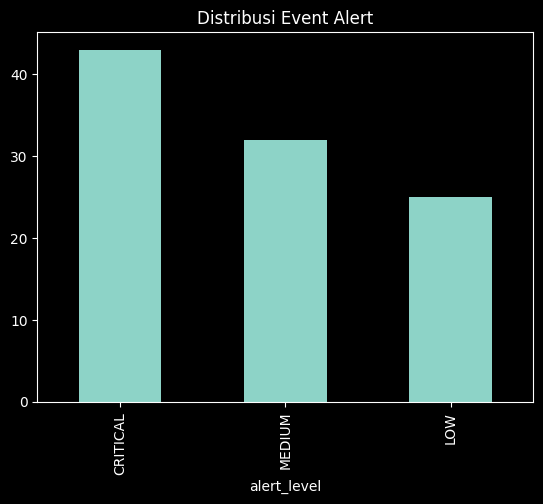

In [143]:
#visualisasi alert
stream_df['alert_level'].value_counts().plot(
    kind='bar'
)
plt.title('Distribusi Event Alert')
plt.show()

In [144]:
#menyimpan csv
stream_df.to_csv(
    'event_alert_stream.csv',
    index=False
)

In [145]:
from google.colab import files

files.download('event_alert_stream.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Berikan rekomendasi mitigasi untuk masing-masing pola risiko.

In [ ]:
print("1. Integrasi HR & IT: Otomatis matikan (disable) akun saat karyawan resign.")
print("2. Terapkan DLP (Data Loss Prevention) untuk memblokir download data rahasia dalam jumlah besar.")
print("3. Terapkan peringatan real-time jika ada aktivitas dari IP yang tidak dikenal (eksternal).")

In [ ]:
print("\n[3.4] REKOMENDASI MITIGASI")

In [ ]:
mitigasi = {
    "Pola 1 - Terminated User": [
        "Nonaktifkan akun otomatis saat karyawan keluar (offboarding otomatis)",
        "Audit akun secara berkala untuk cari akun yang belum dinonaktifkan",
        "Terapkan Zero Trust: semua sesi harus diverifikasi ulang",
    ],
    "Pola 2 - Download Besar Data Sensitif": [
        "Pasang DLP (Data Loss Prevention) untuk blokir transfer data besar tanpa izin",
        "Enkripsi semua aset confidential dan restricted",
        "Batasi akses hanya ke aset yang benar-benar dibutuhkan (least privilege)",
    ],
    "Pola 3 - Permission Change dari IP Eksternal": [
        "Batasi permission change hanya dari jaringan internal atau VPN",
        "Wajibkan MFA (Multi-Factor Authentication) untuk ubah hak akses",
        "Setiap perubahan hak akses butuh persetujuan minimal 2 orang",
    ],
    "Pola 4 - Clearance Mismatch": [
        "Blokir otomatis jika clearance user lebih rendah dari klasifikasi aset",
        "Periksa clearance semua karyawan saat onboarding dan review berkala",
        "Kirim alert ke tim keamanan jika mismatch terdeteksi",
    ],
}

for pola, tips in mitigasi.items():
    print(f"\n{pola}:")
    for tip in tips:
        print(f"  - {tip}")

In [151]:
!streamlit run app.py &>/content/logs.txt &

In [148]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://dry-kiwis-wave.loca.lt
^C
